## 0. Import thư viện

In [ ]:
import sys, io, os, warnings, datetime, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
import joblib

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)

SRC_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
print(f'Working dir: {os.getcwd()}')

_old = sys.stdout, sys.stderr
sys.stdout = sys.stderr = io.StringIO()
from vnstock import stock_historical_data as fetch_ohlcv
sys.stdout, sys.stderr = _old

print('Pass')

Working dir: /
✅ Import thành công


---
## Bước 1 — Cấu hình


In [ ]:
HORIZON   = 5     
THRESHOLD = 2.5
MODE = "BINARY"   

STOCKS = [
    "VCB","TCB","BID","ACB","HDB","MBB","CTG","VPB","TPB","STB","EIB","SHB","VIB","LPB","OCB",
    "VIC","VHM","VRE","NVL","PDR","DXG","KDH",
    "FPT",
    "VNM","MWG","MSN","SAB","PNJ","DHG","MCH",
    "GAS","PLX","HPG","HOA","DGC","POW",
    "SSI","VND","HCM",
    "REE","GMD","HAG",
]

FEATURES = [
    "ret_1","ret_3","ret_5","ret_10","ret_20",         
    "ema5_ratio","ema20_ratio","ema5_ema20",               
    "rsi","macd_hist","bb_pos",                           
    "atr_ratio","vol_ratio",                               
    "stoch_k","williams_r",                                
    "high20_dist","low20_dist",                            
]

print(f"Config:")
print(f"  Horizon   : {HORIZON} phiên")
print(f"  Threshold : ±{THRESHOLD}%")
print(f"  Mode      : {MODE}")
print(f"  Số mã     : {len(STOCKS)}")
print(f"  Features  : {len(FEATURES)}")


Config:
  Horizon   : 5 phiên
  Threshold : ±2.5%
  Mode      : BINARY
  Số mã     : 42
  Features  : 17


---
## Bước 2 — Feature Engineering



In [ ]:
def compute_features(df):
    """
    Tính 12 chỉ số kỹ thuật (features) từ dữ liệu OHLCV thô.

    Tất cả hàm tính toán đều là built-in của pandas:
      - pct_change(N) : % thay đổi so với N hàng trước → pandas built-in
      - ewm(span=N)   : Exponential Weighted Moving average → pandas built-in
      - rolling(N)    : cửa sổ trượt N ngày → pandas built-in
      - diff()        : hiệu 2 dòng liên tiếp → pandas built-in
      - clip()        : giới hạn giá trị min/max → pandas built-in
    """

    df = df.copy().sort_values("time").reset_index(drop=True)

    df["ret_1"]  = df["close"].pct_change(1)  * 100   
    df["ret_3"]  = df["close"].pct_change(3)  * 100   
    df["ret_5"]  = df["close"].pct_change(5)  * 100   
    df["ret_10"] = df["close"].pct_change(10) * 100   


    df["ema5"]  = df["close"].ewm(span=5,  adjust=False).mean()
    df["ema20"] = df["close"].ewm(span=20, adjust=False).mean()

    df["ema5_ratio"]  = (df["close"] / df["ema5"]  - 1) * 100
    df["ema20_ratio"] = (df["close"] / df["ema20"] - 1) * 100

    df["ema5_ema20"]  = (df["ema5"] / df["ema20"] - 1) * 100

    delta = df["close"].diff()

    avg_gain = delta.clip(lower=0).ewm(com=13, adjust=False).mean()

    avg_loss = (-delta.clip(upper=0)).ewm(com=13, adjust=False).mean()

    df["rsi"] = 100 - 100 / (1 + avg_gain / (avg_loss + 1e-9))

    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26

    df["macd_hist"] = (macd - macd.ewm(span=9, adjust=False).mean()) / df["close"] * 100

    ma20  = df["close"].rolling(20).mean()   
    std20 = df["close"].rolling(20).std()    

    df["bb_pos"] = ((df["close"] - (ma20 - 2*std20)) / (4*std20 + 1e-9)).clip(0, 1)

    df["atr_ratio"] = (df["high"] - df["low"]) / df["close"] * 100

    if "volume" in df.columns and df["volume"].sum() > 0:
        vol_ma = df["volume"].rolling(20).mean()   
        df["vol_ratio"] = df["volume"] / (vol_ma + 1)
    else:
        df["vol_ratio"] = 1.0   


 
    low14  = df["low"].rolling(14).min()    
    high14 = df["high"].rolling(14).max()   
    df["stoch_k"] = ((df["close"] - low14) / (high14 - low14 + 1e-9) * 100).clip(0, 100)


    df["williams_r"] = ((high14 - df["close"]) / (high14 - low14 + 1e-9) * -100).clip(-100, 0)

    df["ret_20"] = df["close"].pct_change(20) * 100

    high20 = df["high"].rolling(20).max()
    low20  = df["low"].rolling(20).min()
    df["high20_dist"] = (df["close"] / high20 - 1) * 100   
    df["low20_dist"]  = (df["close"] / low20  - 1) * 100   

    return df

print("Hàm compute_features OK")

✅ Hàm compute_features đã sẵn sàng


---
## Bước 3 — Thu thập dữ liệu 40 mã



In [ ]:
def fetch_stock(symbol):
    """Fetch 3 năm OHLCV cho 1 mã (tăng từ 2 → 3 năm để có nhiều mẫu hơn)."""
    end   = datetime.date.today().isoformat()
    start = (datetime.date.today() - datetime.timedelta(days=1095)).isoformat()
    _old = sys.stdout, sys.stderr
    sys.stdout = sys.stderr = io.StringIO()
    try:
        df = fetch_ohlcv(symbol, start, end, "1D")
    except Exception:
        df = None
    finally:
        sys.stdout, sys.stderr = _old
    return df


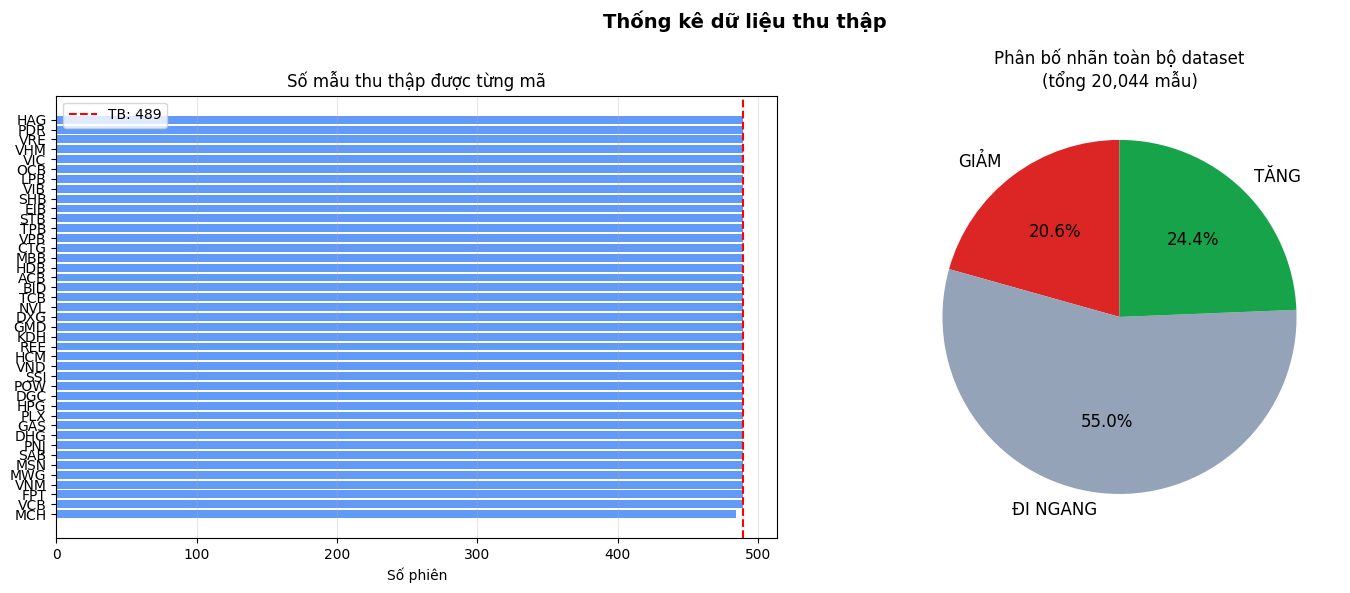

In [ ]:
stats_df = pd.DataFrame(stock_stats).sort_values('n', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_bar = ['#3b82f6'] * len(stats_df)
axes[0].barh(stats_df['symbol'], stats_df['n'], color=colors_bar, alpha=0.8)
axes[0].set_title('Số mẫu thu thập được từng mã')
axes[0].set_xlabel('Số phiên')
axes[0].axvline(stats_df['n'].mean(), color='red', linestyle='--',
                label=f'TB: {stats_df["n"].mean():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='x')

combined_temp = pd.concat(all_frames, ignore_index=True)
lbl_counts = combined_temp['label'].value_counts().sort_index()
labels_name = {-1: 'GIẢM', 0: 'ĐI NGANG', 1: 'TĂNG'}
colors_pie  = ['#dc2626', '#94a3b8', '#16a34a']
axes[1].pie(
    [lbl_counts.get(k, 0) for k in [-1, 0, 1]],
    labels=[labels_name[k] for k in [-1, 0, 1]],
    colors=colors_pie, autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title(f'Phân bố nhãn toàn bộ dataset\n(tổng {total:,} mẫu)')

plt.suptitle('Thống kê dữ liệu thu thập', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Bước 4 — Gộp dataset và chia Train/Test



In [ ]:
combined = pd.concat(all_frames, ignore_index=True).dropna()

if MODE == "BINARY":
    n_flat = (combined["label"] == 0).sum()
    combined = combined[combined["label"] != 0].copy()
    print(f"BINARY mode: bỏ {n_flat} mẫu ĐI NGANG")

X     = combined[FEATURES].values
y_cls = combined["label"].values
y_ret = combined["future_return"].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

split = int(len(X_scaled) * 0.8)
X_tr, X_te   = X_scaled[:split], X_scaled[split:]
yc_tr, yc_te = y_cls[:split],    y_cls[split:]
yr_tr        = y_ret[:split]

print(f"Dataset tổng : {len(combined):,} mẫu (sau lọc mode={MODE})")
print(f"  Train: {len(X_tr):,} mẫu (80%)")
print(f"  Test:  {len(X_te):,} mẫu (20%)")
print(f"Phân bố nhãn train: {dict(Counter(yc_tr.tolist()))}")
print(f"Phân bố nhãn test:  {dict(Counter(yc_te.tolist()))}")


BINARY mode: bỏ 11023 mẫu ĐI NGANG
Dataset tổng : 9,021 mẫu (sau lọc mode=BINARY)
  Train: 7,216 mẫu (80%)
  Test:  1,805 mẫu (20%)
Phân bố nhãn train: {1: 3911, -1: 3305}
Phân bố nhãn test:  {1: 972, -1: 833}


IndexError: index 12 is out of bounds for axis 0 with size 12

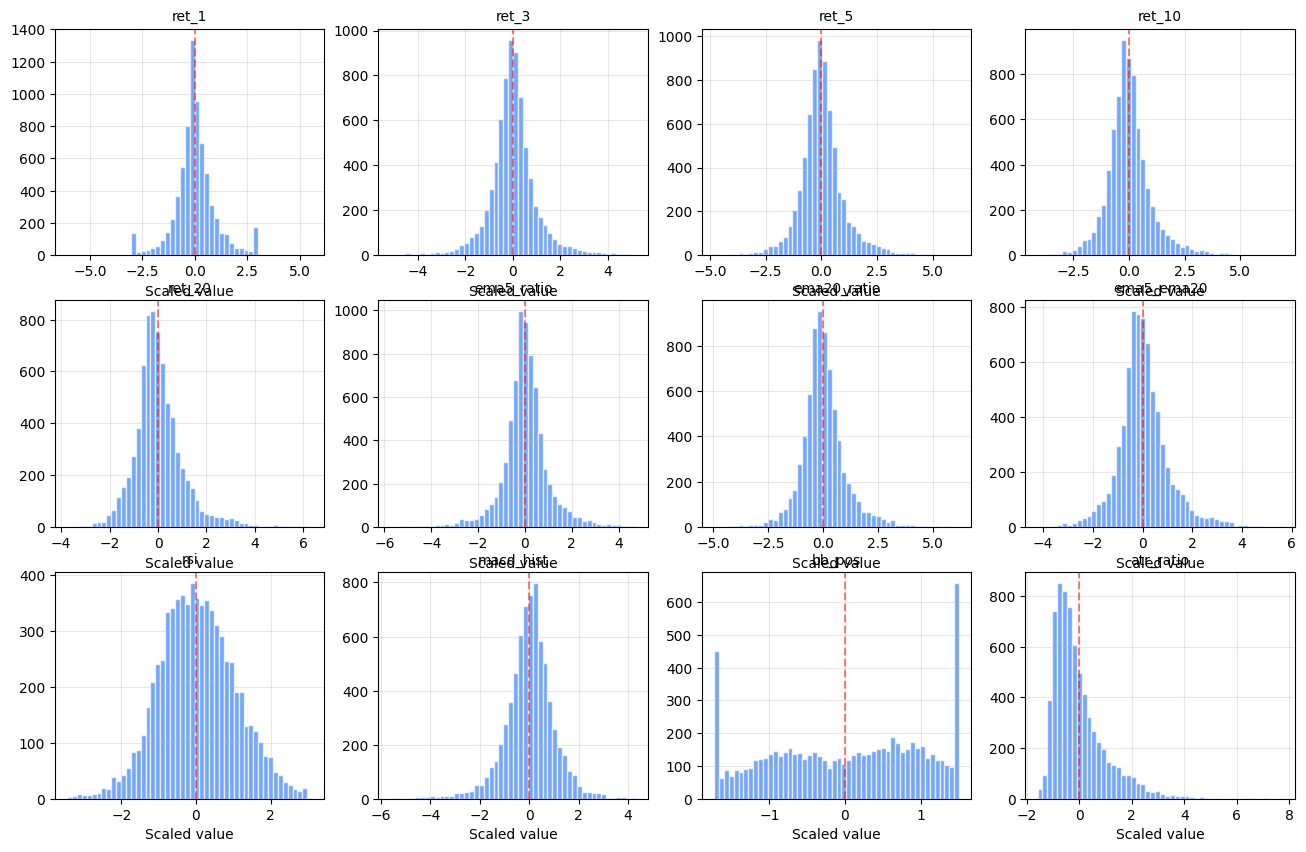

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    vals = X_tr[:, i]
    axes[i].hist(vals, bins=50, color='#3b82f6', edgecolor='white', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_xlabel('Scaled value')
    axes[i].grid(alpha=0.3)

plt.suptitle('Phân phối features sau StandardScaler (mean≈0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Bước 5 — Huấn luyện mô hình (Training)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor


print(f"Training Gradient Boosting Classifier (mode={MODE})...")
clf = GradientBoostingClassifier(
    n_estimators=300,      
    learning_rate=0.05,    
    max_depth=4,           
    min_samples_leaf=15,   
    subsample=0.8,         
    max_features="sqrt",   
    random_state=42,
)
clf.fit(X_tr, yc_tr)
acc = accuracy_score(yc_te, clf.predict(X_te))

baseline = 50.0 if MODE == "BINARY" else 33.3
print(f"Gradient Boosting — Accuracy: {acc:.2%}")
print(f"   Random guess baseline : {baseline:.1f}%")
print(f"   Cải thiện so với baseline: +{acc*100 - baseline:.1f}%")

# So sánh nhanh với RF
print("So sánh nhanh với Random Forest...")
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=15,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_clf.fit(X_tr, yc_tr)
rf_acc = accuracy_score(yc_te, rf_clf.predict(X_te))
print(f"  Random Forest     : {rf_acc:.2%}")
print(f"  Gradient Boosting : {acc:.2%}")
print(f"  → Dùng model tốt hơn: {'Gradient Boosting' if acc >= rf_acc else 'Random Forest'}")

if acc < rf_acc:
    clf = rf_clf
    acc = rf_acc
    print("  → Đã chuyển sang dùng Random Forest")

print("Training Regressor...")
reg = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, min_samples_leaf=15,
    subsample=0.8, random_state=42,
)
reg.fit(X_tr, yr_tr)
print("✅ Regressor xong")


Training Gradient Boosting Classifier (mode=BINARY)...
Gradient Boosting — Accuracy: 56.84%
   Random guess baseline : 50.0%
   Cải thiện so với baseline: +6.8%
So sánh nhanh với Random Forest...
  Random Forest     : 55.79%
  Gradient Boosting : 56.84%
  → Dùng model tốt hơn: Gradient Boosting
Training Regressor...
✅ Regressor xong


---
## Bước 6 — Đánh giá mô hình (Evaluation)

In [ ]:
y_pred = clf.predict(X_te)

if MODE == "BINARY":
    target_names = ["GIẢM", "TĂNG"]
    baseline_str = "50.00%"
else:
    target_names = ["GIẢM", "ĐI NGANG", "TĂNG"]
    baseline_str = "33.33%"

print(f"=== Kết quả trên Test Set ({len(X_te):,} mẫu) ===")
print(f"Accuracy: {acc:.2%}  (Random guess = {baseline_str})")
print()
print(classification_report(yc_te, y_pred, target_names=target_names, zero_division=0))


=== Kết quả trên Test Set (1,805 mẫu) ===
Accuracy: 56.84%  (Random guess = 50.00%)

              precision    recall  f1-score   support

        GIẢM       0.54      0.48      0.51       833
        TĂNG       0.59      0.64      0.62       972

    accuracy                           0.57      1805
   macro avg       0.56      0.56      0.56      1805
weighted avg       0.57      0.57      0.57      1805



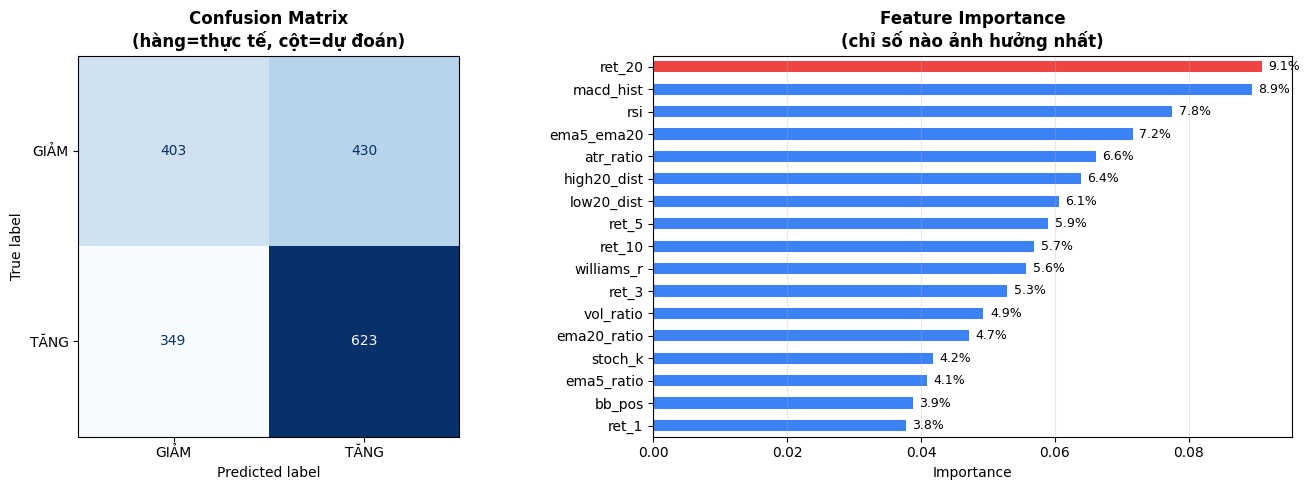


Top 5 features quan trọng nhất:
  ret_20            9.1%  ██████████████████
  macd_hist         8.9%  █████████████████
  rsi               7.8%  ███████████████
  ema5_ema20        7.2%  ██████████████
  atr_ratio         6.6%  █████████████


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if MODE == "BINARY":
    cm_labels        = [-1, 1]
    cm_display_names = ["GIẢM", "TĂNG"]
else:
    cm_labels        = [-1, 0, 1]
    cm_display_names = ["GIẢM", "ĐI NGANG", "TĂNG"]

cm = confusion_matrix(yc_te, y_pred, labels=cm_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=cm_display_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix\n(hàng=thực tế, cột=dự đoán)", fontweight="bold")

feat_imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors_fi = ["#ef4444" if v == feat_imp.max() else "#3b82f6" for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=axes[1], color=colors_fi)
axes[1].set_title("Feature Importance\n(chỉ số nào ảnh hưởng nhất)", fontweight="bold")
axes[1].set_xlabel("Importance")
axes[1].grid(alpha=0.3, axis="x")
for i, v in enumerate(feat_imp.values):
    axes[1].text(v + 0.001, i, f"{v*100:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 features quan trọng nhất:")
for fname, fimp in feat_imp.sort_values(ascending=False).head(5).items():
    bar = "█" * int(fimp * 200)
    print(f"  {fname:15s} {fimp*100:5.1f}%  {bar}")


=== Accuracy theo mức Confidence ===
  >= Conf    Số mẫu   Accuracy   Cải thiện
--------------------------------------------------
  >= 50%    1,805      56.8%   +  6.8%  ██████
  >= 55%    1,083      60.8%   + 10.8%  ██████████
  >= 60%      589      64.3%   + 14.3%  ██████████████
  >= 65%      318      68.6%   + 18.6%  ██████████████████
  >= 70%      178      73.0%   + 23.0%  ███████████████████████
  >= 75%      106      74.5%   + 24.5%  ████████████████████████
  >= 80%       67      77.6%   + 27.6%  ███████████████████████████

Tong mau test     : 1,805
Confidence >= 60% : 589 mau (33%) — Accuracy: 64.3%
-> Chi hien thi du doan khi confidence >= 60%


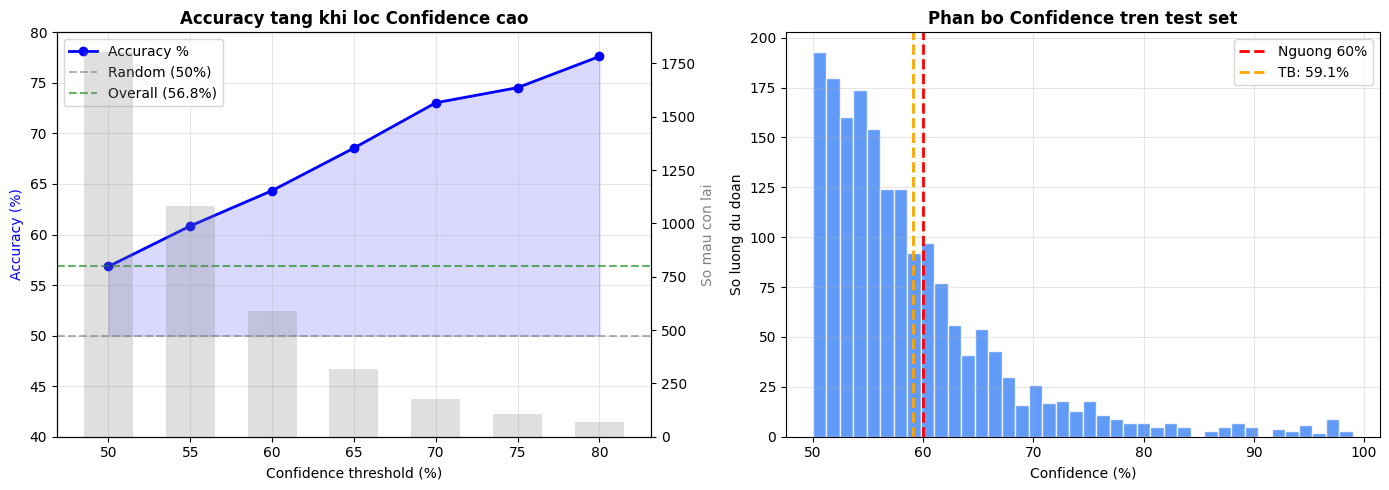

In [ ]:
proba     = clf.predict_proba(X_te)
max_proba = proba.max(axis=1)

print("=== Accuracy theo mức Confidence ===")
print(f"  {chr(62)}{chr(61)} Conf    Số mẫu   Accuracy   Cải thiện")
print("-" * 50)
thresholds, accs, ns = [], [], []
baseline = 50.0 if MODE == "BINARY" else 33.3
for t in np.arange(0.50, 0.80, 0.05):
    mask = max_proba >= t
    if mask.sum() >= 20:
        a = accuracy_score(yc_te[mask], clf.predict(X_te)[mask])
        n = int(mask.sum())
        improvement = a * 100 - baseline
        thresholds.append(t); accs.append(a); ns.append(n)
        bar = chr(9608) * int(improvement)
        print(f"  >= {t*100:.0f}%   {n:>6,}   {a*100:>7.1f}%   +{improvement:>5.1f}%  {bar}")

print()
mask60        = max_proba >= 0.6
n_high        = int(mask60.sum())
pct_high      = mask60.mean() * 100
acc_high      = accuracy_score(yc_te[mask60], clf.predict(X_te)[mask60]) if n_high > 0 else 0
print(f"Tong mau test     : {len(X_te):,}")
print(f"Confidence >= 60% : {n_high:,} mau ({pct_high:.0f}%) — Accuracy: {acc_high:.1%}")
print("-> Chi hien thi du doan khi confidence >= 60%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(np.array(thresholds)*100, np.array(accs)*100, "b-o", lw=2, label="Accuracy %")
ax1.axhline(baseline, color="gray", ls="--", alpha=0.6, label=f"Random ({baseline:.0f}%)")
ax1.axhline(acc*100, color="green", ls="--", alpha=0.6, label=f"Overall ({acc:.1%})")
ax1.fill_between(np.array(thresholds)*100, baseline, np.array(accs)*100, alpha=0.15, color="blue")
ax1.set_xlabel("Confidence threshold (%)")
ax1.set_ylabel("Accuracy (%)", color="blue")
ax1.set_ylim(40, 80)
ax1.set_title("Accuracy tang khi loc Confidence cao", fontweight="bold")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)
ax2.bar(np.array(thresholds)*100, ns, width=3, alpha=0.25, color="gray")
ax2.set_ylabel("So mau con lai", color="gray")

mean_conf = max_proba.mean() * 100
axes[1].hist(max_proba*100, bins=40, color="#3b82f6", edgecolor="white", alpha=0.8)
axes[1].axvline(60, color="red", lw=2, ls="--", label="Nguong 60%")
axes[1].axvline(mean_conf, color="orange", lw=2, ls="--", label=f"TB: {mean_conf:.1f}%")
axes[1].set_xlabel("Confidence (%)")
axes[1].set_ylabel("So luong du doan")
axes[1].set_title("Phan bo Confidence tren test set", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Bước 7 — Lưu model ra file 



In [ ]:
ML_DIR = os.path.join(os.path.dirname(os.path.abspath("train_model.ipynb")), "")
if not os.path.isdir(ML_DIR):
    ML_DIR = os.getcwd()

SAVE_DIR = os.path.dirname(os.path.abspath("train_model.ipynb"))
if not os.access(SAVE_DIR, os.W_OK):
    SAVE_DIR = os.path.expanduser("~/Desktop/vietnam-monitor/src/ml")
os.makedirs(SAVE_DIR, exist_ok=True)

clf_path  = os.path.join(SAVE_DIR, "model_clf.pkl")
reg_path  = os.path.join(SAVE_DIR, "model_reg.pkl")
scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")
meta_path = os.path.join(SAVE_DIR, "metadata.json")

joblib.dump(clf,    clf_path)
joblib.dump(reg,    reg_path)
joblib.dump(scaler, scaler_path)

feat_imp_dict = {f: round(float(v), 4) for f, v in zip(FEATURES, clf.feature_importances_)}
metadata = {
    "trained_at":          datetime.datetime.now().isoformat(),
    "n_stocks":            len(all_frames),
    "n_samples":           int(len(combined)),
    "accuracy":            round(float(acc), 4),
    "horizon":             HORIZON,
    "threshold":           THRESHOLD,
    "mode":                MODE,
    "features":            FEATURES,
    "feature_importances": feat_imp_dict,
    "stocks_used":         [s for s in STOCKS if s not in failed],
    "stocks_failed":       failed,
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Luu vao: {SAVE_DIR}")
print(f"  model_clf.pkl  — {os.path.getsize(clf_path)//1024:,} KB")
print(f"  model_reg.pkl  — {os.path.getsize(reg_path)//1024:,} KB")
print(f"  scaler.pkl     — {os.path.getsize(scaler_path):,} bytes")
print(f"  metadata.json  — OK")
print()
print(f"  Accuracy  : {acc:.2%}")
print(f"  Train mau : {len(X_tr):,}")
print(f"  Test mau  : {len(X_te):,}")
print(f"  Ma dung   : {len(all_frames)}")
print(f"  Ngay train: {datetime.date.today()}")
print()
print("-> Restart Flask server de load model moi:")
print("   python3 process_data.py")


Luu vao: /Users/datvu/Desktop/vietnam-monitor/src/ml
  model_clf.pkl  — 607 KB
  model_reg.pkl  — 380 KB
  scaler.pkl     — 1,007 bytes
  metadata.json  — OK

  Accuracy  : 56.84%
  Train mau : 7,216
  Test mau  : 1,805
  Ma dung   : 41
  Ngay train: 2026-03-20

-> Restart Flask server de load model moi:
   python3 process_data.py


---
## Bước 8 — Test thử dự đoán 1 mã



In [ ]:
TEST_SYMBOL = 'FPT'   

_old = sys.stdout, sys.stderr
sys.stdout = sys.stderr = io.StringIO()
df_test = fetch_ohlcv(TEST_SYMBOL,
    (datetime.date.today() - datetime.timedelta(days=120)).isoformat(),
    datetime.date.today().isoformat(), '1D')
sys.stdout, sys.stderr = _old

df_test = compute_features(df_test)
X_today = df_test[FEATURES].dropna().iloc[[-1]].values
X_today_scaled = scaler.transform(X_today)

pred_cls   = int(clf.predict(X_today_scaled)[0])
pred_proba = clf.predict_proba(X_today_scaled)[0]
pred_ret   = float(reg.predict(X_today_scaled)[0])
classes    = clf.classes_.tolist()
confidence = pred_proba[classes.index(pred_cls)] * 100

dir_map = {1: '▲ TĂNG', 0: '→ ĐI NGANG', -1: '▼ GIẢM'}

print(f'=== Dự đoán {TEST_SYMBOL} ({datetime.date.today()}) ===')
print(f'Giá gần nhất : {int(df_test["close"].iloc[-1]):,} VNĐ')
print(f'Dự đoán      : {dir_map[pred_cls]}')
print(f'Biến động KV : {pred_ret:+.2f}% trong {HORIZON} phiên')
print(f'Confidence   : {confidence:.1f}%')
print()
for code, name in [(-1,'GIẢM'),(0,'ĐI NGANG'),(1,'TĂNG')]:
    if code in classes:
        p = pred_proba[classes.index(code)] * 100
        bar = '█' * int(p / 4)
        print(f'  {name:10s}: {p:5.1f}%  {bar}')

print(f'\n⚠ Không phải tư vấn đầu tư')

=== Dự đoán FPT (2026-03-20) ===
Giá gần nhất : 76,800 VNĐ
Dự đoán      : ▲ TĂNG
Biến động KV : +2.39% trong 5 phiên
Confidence   : 80.4%

  GIẢM      :  19.6%  ████
  TĂNG      :  80.4%  ████████████████████

⚠ Không phải tư vấn đầu tư
